In [55]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import scipy.stats as stats
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


## Loading Data

In [56]:
# Load the dataset
df = pd.read_csv('../../datasets/DB_data_2025-10.csv', sep=',')
df.sample(5)

,station_name,xml_station_name,eva,train_name,final_destination_station,delay_in_min,time,is_canceled,train_type,train_line_ride_id,train_line_station_num,arrival_planned_time,arrival_change_time,departure_planned_time,departure_change_time,id
1313012,Berlin Zoologischer Garten,Berlin Zoologischer Garten (S),8089046,S 9,Flughafen BER (S-Bahn),0,2025-10-21 16:19:00,False,S,NaN,10,2025-10-21 16:18:00,2025-10-21 16:18:00,2025-10-21 16:19:00,2025-10-21 16:19:00,-3502234289036778262-2510211557-10
1661845,Saarbrücken Hbf,Saarbrücken Hbf,8000323,RB 73,Saarbrücken Hbf,1,2025-10-27 06:39:00,False,RB,8.891125e+18,22,2025-10-27 06:38:00,2025-10-27 06:39:00,NaN,NaN,8891124794791535566-2510270534-22
948185,Karlsruhe Hbf,Karlsruhe Hbf,8000191,RE 1,Karlsruhe Hbf,2,2025-10-15 19:54:00,False,RE,8.813903e+16,9,2025-10-15 19:52:00,2025-10-15 19:54:00,NaN,NaN,88139029874116301-2510151802-9
1163590,Solingen Hbf,Solingen Hbf,8000087,Bus S1,Solingen Hbf,-4,2025-10-19 09:31:00,False,Bus,NaN,9,2025-10-19 09:35:00,2025-10-19 09:31:00,NaN,NaN,-7709192370530458566-2510190832-9
960983,Köln Hbf,Köln Hbf,8000207,RB 38,Köln Messe/Deutz,51,2025-10-16 01:21:00,False,RB,NaN,9,2025-10-16 00:28:00,2025-10-16 01:20:00,2025-10-16 00:30:00,2025-10-16 01:21:00,-5236850432598843260-2510152343-9


## Data Inspection and Cleaning

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1989180 entries, 0 to 1989179
Data columns (total 16 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   station_name               object 
 1   xml_station_name           object 
 2   eva                        int64  
 3   train_name                 object 
 4   final_destination_station  object 
 5   delay_in_min               int64  
 6   time                       object 
 7   is_canceled                bool   
 8   train_type                 object 
 9   train_line_ride_id         float64
 10  train_line_station_num     int64  
 11  arrival_planned_time       object 
 12  arrival_change_time        object 
 13  departure_planned_time     object 
 14  departure_change_time      object 
 15  id                         object 
dtypes: bool(1), float64(1), int64(3), object(11)
memory usage: 229.5+ MB


In [58]:
# Create table

def format_example_values(series):
    vals = series.dropna().unique()[:5]
    
    formatted = []
    for v in vals:
        if isinstance(v, (int, float, np.number)):
            formatted.append(f"{v:.2f}")
        else:
            formatted.append(str(v))
    return ", ".join(formatted)

summary_df = pd.DataFrame({
    "Feature/variable": df.columns,
    "Data type": df.dtypes.values.astype(str),
    "Number of Unique values": [df[col].nunique() for col in df.columns],
    "Missing values": [df[col].isna().sum() for col in df.columns],
    "Example values": [format_example_values(df[col]) for col in df.columns]
    
})

# Show all rows without truncation
with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    print(summary_df.to_markdown(index=False))

| Feature/variable          | Data type   |   Number of Unique values |   Missing values | Example values                                                                                                                                                            |
|:--------------------------|:------------|--------------------------:|-----------------:|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| station_name              | object      |                       107 |                0 | Hamburg Hbf, München Ost, Köln Hbf, Stuttgart Hbf, Duisburg Hbf                                                                                                           |
| xml_station_name          | object      |                       130 |                0 | Hamburg Hbf, München Ost, Köln Hbf, Stuttgart Hbf, Duisburg Hbf                                                         

In [59]:
# Create table for numeric columns
numeric_cols = ["delay_in_min"]

# Basic descriptive statistics
desc = df[numeric_cols].describe().rename(index={
    "50%": "50%",
    "25%": "25%",
    "75%": "75%"
})

# Add variance
desc.loc["Variance"] = df[numeric_cols].var()

# Add dispersion index = variance / mean
dispersion_index = df[numeric_cols].var() / df[numeric_cols].mean()
desc.loc["Dispersion index (Variance / Mean)"] = dispersion_index

# Reorder rows 
row_order = [
    "count", "mean", "std", "min", "25%", "50%", "75%", "max",
    "Variance", "Dispersion index (Variance / Mean)"
]
desc = desc.loc[row_order]

# Convert to Markdown
md_table = desc.to_markdown(tablefmt="pipe", floatfmt=".2f")
print(md_table)

|                                    |   delay_in_min |
|:-----------------------------------|---------------:|
| count                              |     1989180.00 |
| mean                               |           4.89 |
| std                                |          10.95 |
| min                                |       -1435.00 |
| 25%                                |           0.00 |
| 50%                                |           1.00 |
| 75%                                |           5.00 |
| max                                |         386.00 |
| Variance                           |         119.79 |
| Dispersion index (Variance / Mean) |          24.50 |


In [60]:
# Descriptive table for categorical variables

categorical_cols = df.select_dtypes(include=['object']).columns
cat_desc = pd.DataFrame(index=categorical_cols, columns=[
    "Unique Values"
])

for col in categorical_cols:
    counts = df[col].value_counts(dropna=False)
    most_freq_val = counts.idxmax()
    freq = counts.max()
    perc = freq / counts.sum() * 100

    cat_desc.loc[col] = [
        df[col].nunique()
    ]

# Convert to Markdown
md_table_cat = cat_desc.to_markdown(tablefmt="pipe", floatfmt=".2f")
print(md_table_cat)

|                           |   Unique Values |
|:--------------------------|----------------:|
| station_name              |             107 |
| xml_station_name          |             130 |
| train_name                |            1573 |
| final_destination_station |            1353 |
| time                      |           44530 |
| train_type                |              55 |
| arrival_planned_time      |           44338 |
| arrival_change_time       |           44365 |
| departure_planned_time    |           44353 |
| departure_change_time     |           44354 |
| id                        |         1989180 |


In [61]:
# check mising values
missing_counts = df.isna().sum()
print(missing_counts)

station_name                      0
xml_station_name                  0
eva                               0
train_name                        0
final_destination_station         0
delay_in_min                      0
time                              0
is_canceled                       0
train_type                        0
train_line_ride_id           988616
train_line_station_num            0
arrival_planned_time         446738
arrival_change_time          446699
departure_planned_time       445857
departure_change_time        445805
id                                0
dtype: int64


In [62]:
# check for duplicates 
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [63]:
# compare all values in station_name and xml_station_name and output the differences

station_names = set(df["station_name"].unique())
xml_station_names = set(df["xml_station_name"].unique())
differences = station_names.symmetric_difference(xml_station_names)
print("Values in station_name but not in xml_station_name:", station_names - xml_station_names)
print("Values in xml_station_name but not in station_name:", xml_station_names - station_names)

Values in station_name but not in xml_station_name: {'Landshut (Bay) Hbf', 'Ludwigshafen (Rhein) Hbf', 'Neustadt (Weinstr) Hbf', 'Frankfurt (Main) Hbf', 'Hamm (Westf) Hbf', 'Münster (Westf) Hbf', 'Fürth (Bay) Hbf', 'Frankfurt (Oder)', 'Halle (Saale) Hbf', 'Oldenburg (Oldb) Hbf', 'Berlin Hauptbahnhof', 'Singen (Hohentwiel)', 'Freiburg (Breisgau) Hbf', 'Frankfurt (Main) Süd'}
Values in xml_station_name but not in station_name: {'Oldenburg(Oldb)Hbf', 'Ludwigshafen(Rh)Hbf', 'Halle(Saale)Hbf', 'Frankfurt(Main)Süd', 'München Hbf (tief)', 'Berlin Ostbahnhof (S)', 'Hamm(Westf)Hbf', 'Stuttgart Hbf (tief)', 'Münster(Westf)Hbf', 'München Hbf Gl.5-10', 'Berlin Potsdamer Platz (S)', 'Leipzig Hbf (tief)', 'Berlin Hbf', 'Berlin-Lichtenberg (S)', 'Köln Messe/Deutz Gl.11-12', 'Berlin Friedrichstraße (S)', 'Berlin-Spandau (S)', 'München Hbf Gl.27-36', 'Frankfurt(Main)Hbf', 'Neustadt(Weinstr)Hbf', 'Singen(Hohentwiel)', 'Berlin Ostkreuz (S)', 'Fürth(Bay)Hbf', 'Berlin Gesundbrunnen(S)', 'Frankfurt(Oder)', 

Since station_name column has more clean data, while xml_station_name has some irrelevant data ( duplicates, platform numbers etc.), it is decided to use station_name in analysis.

In [64]:
# Drop extra columns

df.drop(columns=["id", "xml_station_name", "eva", "train_line_ride_id"], inplace=True)


Since destination_name has many unique values, we check for possible duplicates and misspellings

In [65]:
# Create a new column for cleaned destination, remove spaces and dashes
df["cleaned_destination"] = (df["final_destination_station"]
.str.replace(" ", "", regex=False)
.str.replace("-", "", regex=False))

# Remove the S-Bahn marker
df["cleaned_destination"] = (df["cleaned_destination"]
.str.replace("(S)", "", regex=False)
.str.replace("(s)", "", regex=False))

# Fix specific duplicates, swap "(Rh)" for "(Rhein)"
df["cleaned_destination"] = (df["cleaned_destination"]
.str.replace("Terminal", "", regex=False)
.str.replace("(Rh)", "(Rhein)", regex=False))

# Remove "Gl." and track numbers
df["cleaned_destination"] = df["cleaned_destination"].str.replace(r"Gl\.\d*", "", regex=True)

# Print the new number of values
new_unique_count = df["cleaned_destination"].nunique()
print("New number of unique stations:", new_unique_count)

# Insert cleaned column
cleaned_column_data = df.pop("cleaned_destination")
insert_position = df.columns.get_loc("final_destination_station")
df.insert(insert_position, "cleaned_destination", cleaned_column_data)

New number of unique stations: 1320


In [66]:
# Check that there are no rows with both times of arrival and departure missing

missing_both_count = (df["arrival_planned_time"].isna() & df["departure_planned_time"].isna()).sum()
print("Number of rows missing both arrival and departure:", missing_both_count)

Number of rows missing both arrival and departure: 0


In [ ]:
# Detect outliers in delay_in_min
s = df["delay_in_min"].dropna()

summary = s.describe(percentiles=[.001, .01, .05, .5, .95, .99, .999])
neg_rate = (s < 0).mean()
summary, neg_rate, s.min(), s.max()

In [ ]:
# Drop outliers (large negative values likely represent data errors)
df = df[df["delay_in_min"] > -60]

In [ ]:
df

# How much of the variation in train delay duration can be explained by observable operational and structural factors, and what are the limits of predictability?

In [ ]:
# Create a clean copy for modeling
df_clean = df.copy()

In [ ]:
# Clip small negative values to zero, as they likely represent early arrivals, 
# and we want to focus on delay duration
df_clean["delay_model"] = df_clean["delay_in_min"].clip(lower=0)

In [ ]:
df_clean = df[df["delay_in_min"] > -60].copy()
df_clean["delay_model"] = df_clean["delay_in_min"].clip(lower=0)

s = df_clean["delay_model"]

lo, hi = s.quantile([0.01, 0.99])

plt.figure()
plt.hist(s[(s >= lo) & (s <= hi)], bins=60)
plt.title("Delay distribution (clipped at 0, 1st–99th percentile)")
plt.xlabel("delay_model")
plt.ylabel("count")
plt.show()

lo, hi


Interpretation: 
At 0:
- Large spike: Many trains are exactly on time (or early and clipped to 0)
- Zero Heavy

After zero:
- Rapid decay
- Long tail extending beyond 50 minutes
- Most delays are small (< 10 min)

Implies:
1. Normality assumption is clearly violated.
2. Variance increases with mean.
3. OLS residuals will likely be heteroskedastic.

In [ ]:
# Create log target
df_clean["log_delay"] = np.log1p(df_clean["delay_model"])

In [ ]:
# Convert planned times to datetime, coerce errors to NaT
df_clean["departure_planned_time"] = pd.to_datetime(
    df_clean["departure_planned_time"],
    errors="coerce"
)

# Drop rows with invalid planned departure times using .loc to avoid SettingWithCopyWarning
df_clean = df_clean.loc[df_clean["departure_planned_time"].notna()]

# Create features from planned departure time
df_clean["dep_hour"] = df_clean["departure_planned_time"].dt.hour
df_clean["dep_dow"] = df_clean["departure_planned_time"].dt.dayofweek
df_clean["dep_month"] = df_clean["departure_planned_time"].dt.month
df_clean["is_weekend"] = (df_clean["dep_dow"] >= 5).astype(int)

df_clean[["dep_hour","dep_dow","dep_month","is_weekend"]].head()

In [ ]:
# Recreate log target
df_clean["delay_model"] = df_clean["delay_in_min"].clip(lower=0)
df_clean["log_delay"] = np.log1p(df_clean["delay_model"])

In [ ]:
# Plot histogram of log delay
plt.figure()
plt.hist(df_clean["log_delay"], bins=60)
plt.title("Log-transformed delay distribution")
plt.xlabel("log_delay")
plt.ylabel("count")
plt.show()

In [ ]:
# Define a minimal first model of numeric variables to diagnose assumptions 
# and understand the data better
features_num = [
    "train_line_station_num",
    "dep_hour",
    "dep_dow",
    "dep_month",
    "is_weekend"
]

df_diag = df_clean[features_num + ["log_delay"]].dropna()
df_diag.shape


In [ ]:
# Split into train and test sets
X = df_diag[features_num]
y = df_diag["log_delay"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Fit the log linear model
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
residuals = y_test - y_pred

In [ ]:
# Print performance metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

r2, rmse, mae

In [ ]:
# Residual histogram
plt.figure()
plt.hist(residuals, bins=60)
plt.title("Residual Distribution (log model)")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

In [ ]:
# Residuals vs. fitted values
plt.figure()
plt.scatter(y_pred, residuals, s=10)
plt.axhline(0)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

In [ ]:
# QQ plot of residuals
plt.figure()
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

Log-Transformed Regression: Summary
- Target variable defined as log(1+delay) to address strong right-skewness and zero-heavy distribution.
- Baseline model (operational + positional variables only) explains ~4% of variance (R² ≈ 0.04).
- Residuals are still slightly right-skewed but improved
- Some heteroskedasticity remains, though not severe given the large sample size.
- Normality is not perfectly satisfied in the tails, which is expected for heavy-tailed delay data.
- Overall, simple temporal and line-position variables explain only a small share of delay variation. In the next step, we include structural factors (e.g., train type and station) to evaluate how much additional variation can be explained and to better assess the limits of predictability.

In [ ]:
# Check unique values in station_name, train_type, and cleaned_destination
df_clean["station_name"].nunique()
df_clean["train_type"].nunique()
df_clean["cleaned_destination"].nunique()

print(f"Unique stations: {df_clean['station_name'].nunique()}")
print(f"Unique train types: {df_clean['train_type'].nunique()}")
print(f"Unique cleaned destinations: {df_clean['cleaned_destination'].nunique()}")

In [ ]:
# Numeric features
num_cols = [
    "train_line_station_num",
    "dep_hour",
    "dep_dow",
    "dep_month",
    "is_weekend"
]

# Categorical features for Model 2
cat_cols_m2 = ["train_type"]

# Categorical features for Model 3
cat_cols_m3 = ["train_type", "station_name"]

In [ ]:
df_model = df_clean[num_cols + ["train_type", "station_name", "log_delay"]].dropna()

X = df_model[num_cols + ["train_type", "station_name"]]
y = df_model["log_delay"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
preprocess_m2 = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_m2),
        ("num", "passthrough", num_cols)
    ]
)

model_m2 = Pipeline([
    ("preprocess", preprocess_m2),
    ("ridge", Ridge(alpha=1.0))
])

model_m2.fit(X_train, y_train)
pred_m2 = model_m2.predict(X_test)

r2_m2 = r2_score(y_test, pred_m2)
rmse_m2 = np.sqrt(mean_squared_error(y_test, pred_m2))

r2_m2, rmse_m2

In [ ]:
preprocess_m3 = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_m3),
        ("num", "passthrough", num_cols)
    ]
)

model_m3 = Pipeline([
    ("preprocess", preprocess_m3),
    ("ridge", Ridge(alpha=1.0))
])

model_m3.fit(X_train, y_train)
pred_m3 = model_m3.predict(X_test)

r2_m3 = r2_score(y_test, pred_m3)
rmse_m3 = np.sqrt(mean_squared_error(y_test, pred_m3))

r2_m3, rmse_m3

In [ ]:
# Predictions from final Ridge model
pred_ridge_log = model_m3.predict(X_test)

# Residuals
res_ridge = y_test - pred_ridge_log

In [ ]:
# Residuals
plt.figure()
plt.hist(res_ridge, bins=60)
plt.title("Residual Distribution – Ridge")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

In [ ]:
plt.figure()
plt.scatter(pred_ridge_log, res_ridge, s=10, alpha=0.4)
plt.axhline(0)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted – Ridge")
plt.show()

In [ ]:
# QQ Plot
plt.figure()
stats.probplot(res_ridge, dist="norm", plot=plt)
plt.title("Q-Q Plot – Ridge")
plt.show()

In [ ]:
plt.figure()
plt.scatter(y_test, model_m3.predict(X_test), s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")
plt.xlabel("Observed log(1 + delay)")
plt.ylabel("Predicted log(1 + delay)")
plt.title("Ridge Model: Observed vs Predicted (Log Scale)")
plt.show()

Incremental Model Comparison

- Operational variables alone explain ~4% of delay variation.
- Adding train type increases explanatory power substantially (R² ≈ 0.16).
- Including station identity further improves the model (R² ≈ 0.21).
- Structural characteristics therefore play a significantly larger role than basic scheduling variables. However, even the most comprehensive model explains only about one fifth of delay variation, indicating substantial inherent unpredictability and the likely importance of unobserved operational and environmental factors.

**Are delays nonlinear and can a flexible model substantially improve predictability?**

In [ ]:
# Run a Random Forest benchmark to see if nonlinearity significantly improves R².
# Create subsample for computational efficiency
df_sample = df_model.sample(n=400_000, random_state=42)

X_sample = df_sample[num_cols + ["train_type", "station_name"]]
y_sample = df_sample["log_delay"]

from sklearn.model_selection import train_test_split
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42
)


In [ ]:
# Run on smaller sample for speed
rf_model = Pipeline([
    ("preprocess", preprocess_rf),
    ("rf", RandomForestRegressor(
        n_estimators=100,
        max_depth=20,        # limit depth for speed + regularization
        n_jobs=-1,
        random_state=42
    ))
])

rf_model.fit(X_train_s, y_train_s)

pred_rf = rf_model.predict(X_test_s)

r2_rf = r2_score(y_test_s, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_s, pred_rf))

r2_rf, rmse_rf

In [ ]:
plt.figure()
plt.scatter(y_test_s, pred_rf, s=10)
plt.plot([y_test_s.min(), y_test_s.max()],
         [y_test_s.min(), y_test_s.max()],
         linestyle="--")
plt.xlabel("Observed log(1 + delay)")
plt.ylabel("Predicted log(1 + delay)")
plt.title("Random Forest: Observed vs Predicted (Log Scale)")
plt.show()

In [ ]:
res_ridge = y_test - model_m3.predict(X_test)
res_rf = y_test_s - pred_rf

In [ ]:
# Side by side comparison
plt.figure()
plt.hist(res_ridge, bins=60)
plt.title("Residual Distribution – Ridge")
plt.show()

plt.figure()
plt.hist(res_rf, bins=60)
plt.title("Residual Distribution – Random Forest")
plt.show()

In [ ]:
# Back to minutes
# Ridge
pred_ridge_minutes = np.expm1(model_m3.predict(X_test))
true_minutes = np.expm1(y_test)

# RF
pred_rf_minutes = np.expm1(pred_rf)
true_rf_minutes = np.expm1(y_test_s)

In [ ]:
# Ridge model fit in minutes
plt.figure()
plt.scatter(true_minutes, pred_ridge_minutes,
            s=10, alpha=0.4, color="royalblue")

plt.plot([0, 60],
         [0, 60],
         linestyle="--",
         color="black")

plt.xlim(0, 60)
plt.ylim(0, 60)

plt.xlabel("Observed delay (minutes)")
plt.ylabel("Predicted delay (minutes)")
plt.title("Ridge Model – Fit (0–60 min range)")
plt.show()

In [ ]:
# RF model fit in minutes
plt.figure()

plt.scatter(true_rf_minutes, pred_rf_minutes,
            s=10,
            alpha=0.4,
            color="forestgreen",
            label="Predictions")

plt.plot([0, 60],
         [0, 60],
         linestyle="--",
         color="black",
         label="Perfect fit")

plt.xlim(0, 60)
plt.ylim(0, 60)

plt.xlabel("Observed delay (minutes)")
plt.ylabel("Predicted delay (minutes)")
plt.title("Random Forest – Fit (0–60 min range)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Model comparison summary
models = ["Ridge", "Random Forest"]
r2_vals = [r2_m3, r2_rf]

plt.figure()
plt.bar(models, r2_vals)
plt.ylabel("R²")
plt.title("Model Comparison")
plt.show()

The Random Forest model increases explanatory power to R² ≈ 0.26, compared to 0.21 in the linear Ridge model. This indicates that there are nonlinear relationships and interactions between structural and operational variables. However, even flexible nonlinear modeling explains only about one quarter of total variation in delay duration. This suggests that while delays exhibit structural patterns, a high proportion of variability remains driven by unobserved or stochastic factors, which indicates that there are clear limits to predictability within the available data, and factors such as weather shocks, infrastructure disruptions, network propagation effects, incident randomness, etc. likely play an important role in predicting train delays.

In [ ]:
# permutation importance on original input features
result = permutation_importance(
    rf_model,
    X_test_s,
    y_test_s,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importances = pd.Series(
    result.importances_mean,
    index=X_test_s.columns
).sort_values(ascending=False)

importances

In [ ]:
# Plot feature importance
plt.figure()
importances.plot(kind="bar")
plt.title("Permutation Importance by Feature (Random Forest)")
plt.ylabel("Decrease in model score (approx. importance)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Clustering of stations by delay and cancellation

First, we should build a profile for each station from the data on train rides, normalize and scale data.

In [67]:
station_profiles = df.groupby('station_name').agg(
    avg_delay_min=('delay_in_min', 'mean'),      
    max_delay_min=('delay_in_min', 'max'),       
    cancellation_rate=('is_canceled', 'mean'),   
    total_trains=('train_name', 'count')         
).reset_index()

station_profiles = station_profiles.dropna()

Explore distribution and correlation of delays and number of trains per station

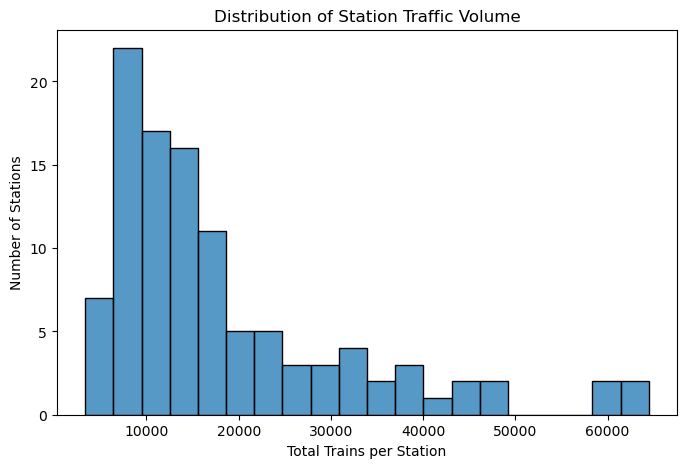

In [68]:
plt.figure(figsize=(8, 5))
sns.histplot(station_profiles['total_trains'], bins=20)

plt.title('Distribution of Station Traffic Volume')
plt.xlabel('Total Trains per Station')
plt.ylabel('Number of Stations')
plt.show()

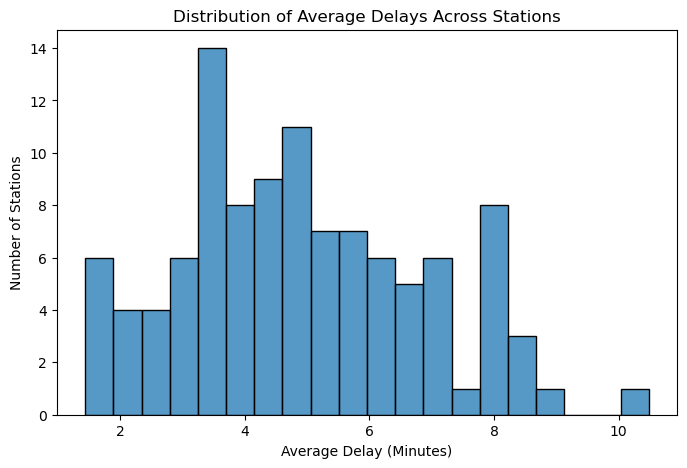

In [69]:
plt.figure(figsize=(8, 5))

sns.histplot(
     station_profiles['avg_delay_min'], 
     bins=20
 )

plt.title('Distribution of Average Delays Across Stations')
plt.xlabel('Average Delay (Minutes)')
plt.ylabel('Number of Stations')
plt.show()

Calculate Pearson correlation value r

In [70]:

# If it close to 0, we don't see a correlation between delays and train volume

correlation = station_profiles['total_trains'].corr(station_profiles['avg_delay_min'])

print(f"Pearson correlation (r) between total traffic and average delay: {correlation:.3f}")

Pearson correlation (r) between total traffic and average delay: -0.018


Since data is skewed, we normalise and scale it for clustering

In [71]:
# log transform number of trains
station_profiles['total_trains_log'] = np.log1p(station_profiles['total_trains'])

# log transform maximum delay data
station_profiles['max_delay_min_log'] = np.log1p(np.abs(station_profiles['max_delay_min']))

# Normalise all data between 0 and 1 to compare it with cancellation rate which is between 0 and 1
features = ['avg_delay_min', 'max_delay_min_log', 'cancellation_rate', 'total_trains_log']
X_stations = station_profiles[features].copy()

# Set up scaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_stations)

Building the dendrogram

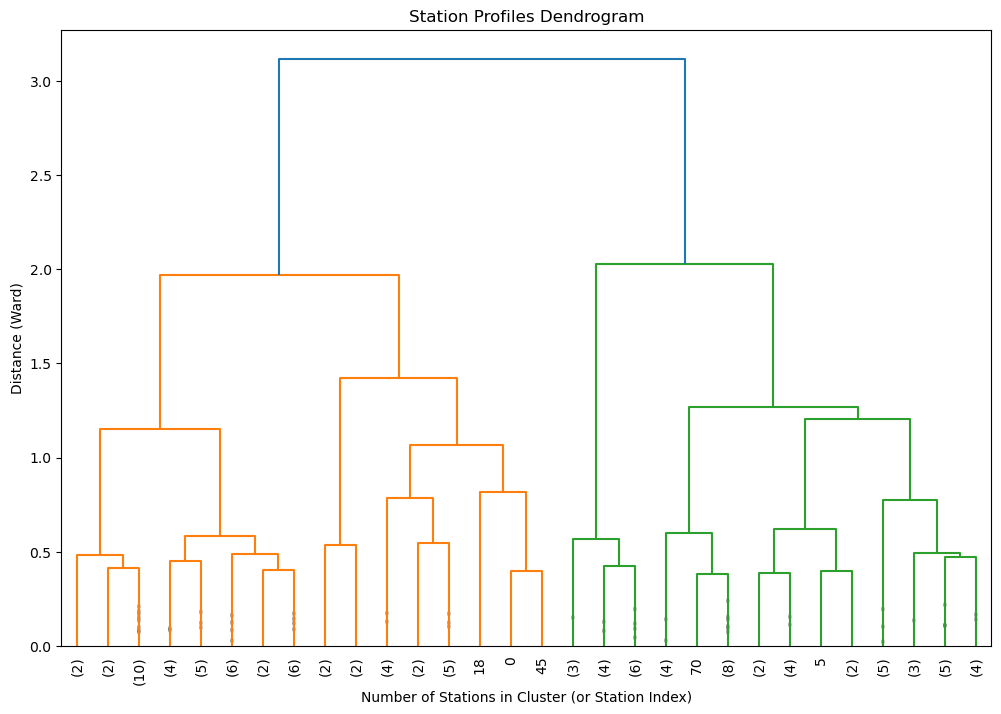

In [72]:
# Linkage matrix
linkage_matrix = linkage(X_scaled, method='ward', metric='euclidean')

# Draw dendrogram
plt.figure(figsize=(12, 8))
plt.title('Station Profiles Dendrogram')
plt.xlabel('Number of Stations in Cluster (or Station Index)')
plt.ylabel('Distance (Ward)')

dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.show()

Cut the dendrogram into clusters

In [73]:
Z = linkage(X_scaled, method='ward', metric='euclidean')

# Cut the dendrogram at height 2.0
clusters_at_height = fcluster(
    Z,
    t=2.0,
    criterion='distance'
)
station_profiles['Cluster_Label'] = clusters_at_height

# Display first 10 rows
print(station_profiles[['station_name', 'Cluster_Label', 'avg_delay_min']].head(10))

             station_name  Cluster_Label  avg_delay_min
0              Aachen Hbf              1       5.774071
1       Aschaffenburg Hbf              1       6.162368
2            Augsburg Hbf              3       5.375354
3            Bad Oldesloe              1       3.538051
4                 Bamberg              1       3.461183
5  Berlin Friedrichstraße              3       2.163861
6    Berlin Gesundbrunnen              3       1.780743
7     Berlin Hauptbahnhof              3       4.916963
8       Berlin Ostbahnhof              3       4.179861
9         Berlin Ostkreuz              3       2.149389


Run PCA

In [74]:
# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame with PCA results
X_pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

# Display variance explained
variance_explained = pca.explained_variance_ratio_
print(f"""
**PCA Results:**
- PC1 explains {variance_explained[0]:.2%} of variance
- PC2 explains {variance_explained[1]:.2%} of variance
- Total variance explained: {variance_explained.sum():.2%}
""")


**PCA Results:**
- PC1 explains 42.23% of variance
- PC2 explains 29.63% of variance
- Total variance explained: 71.87%



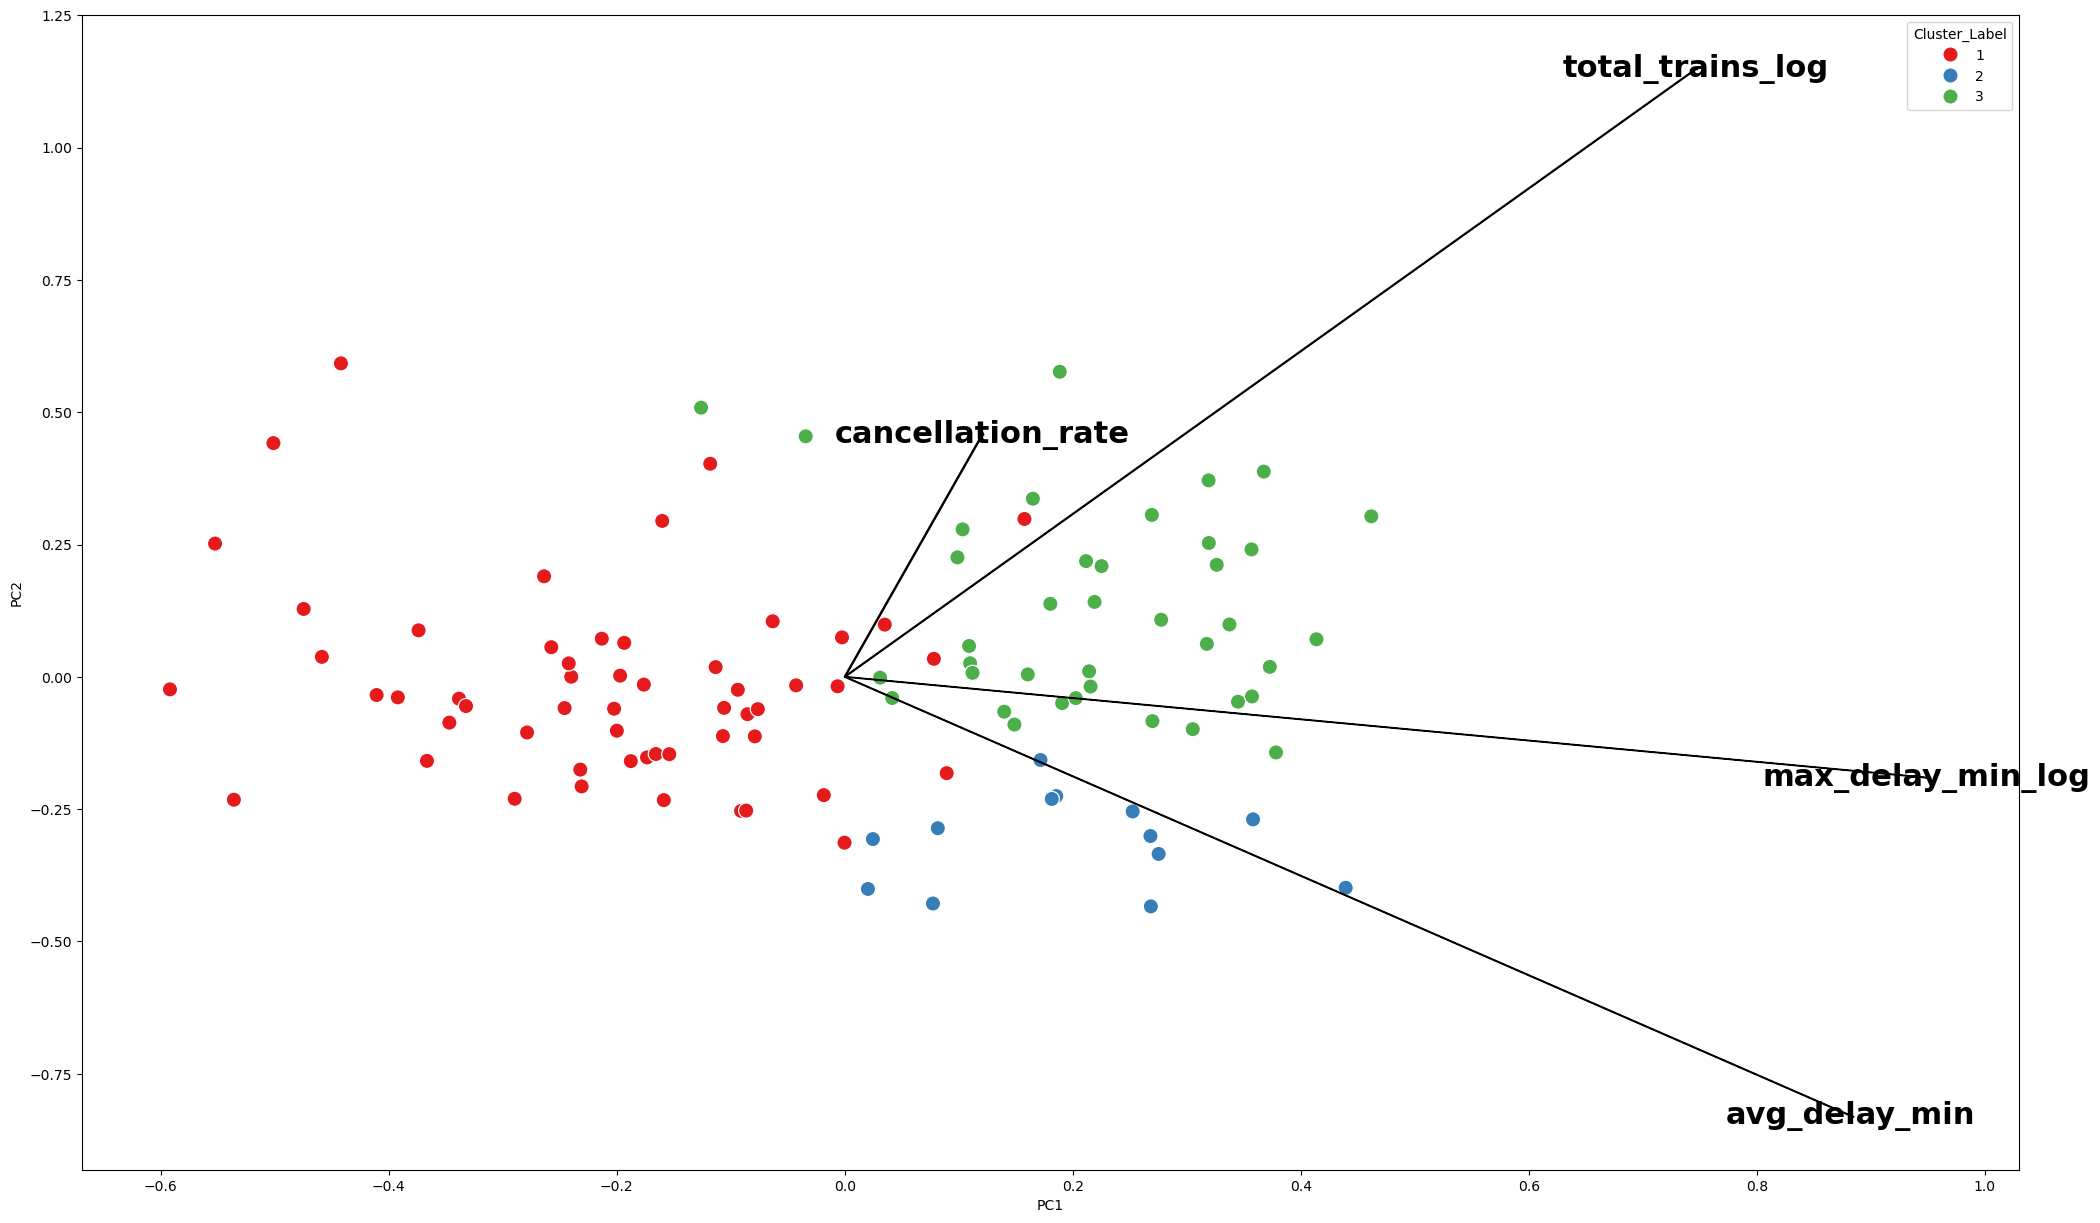

In [75]:
plt.figure(figsize=(25, 15))

station_profiles['PC1'] = pca.transform(X_scaled)[:, 0]
station_profiles['PC2'] = pca.transform(X_scaled)[:, 1]

sns.scatterplot(
    data=station_profiles,
    x='PC1',
    y='PC2',
    hue='Cluster_Label',
    palette='Set1',
    s=120
)

loadings = pca.components_.T * 1.5 
features = ['avg_delay_min', 'max_delay_min_log', 'cancellation_rate', 'total_trains_log']

for i, feature in enumerate(features):
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1])

    plt.text(loadings[i, 0], loadings[i, 1], feature, color='black', ha='center', va='center', fontsize=22, fontweight='bold')

plt.show()

Check that clustering makes sense with silhouette curve:

In [76]:
sil_score = silhouette_score(X_scaled, station_profiles['Cluster_Label'])

# Calculate score using scaled data
# 1 = perfect, 0 = clusters overlap, -1 = very wrong
print(f"Overall Silhouette Score: {sil_score:.3f}")

# Calculate feature means for clusters using original (non-scaled data)
business_columns = [
    'avg_delay_min', 
    'max_delay_min', 
    'cancellation_rate', 
    'total_trains'
]

cluster_summary = station_profiles.groupby('Cluster_Label')[business_columns].mean()

# Count number of stations in each cluster
cluster_summary['number_of_stations'] = station_profiles.groupby('Cluster_Label').size()

Overall Silhouette Score: 0.250


Compare clusters:

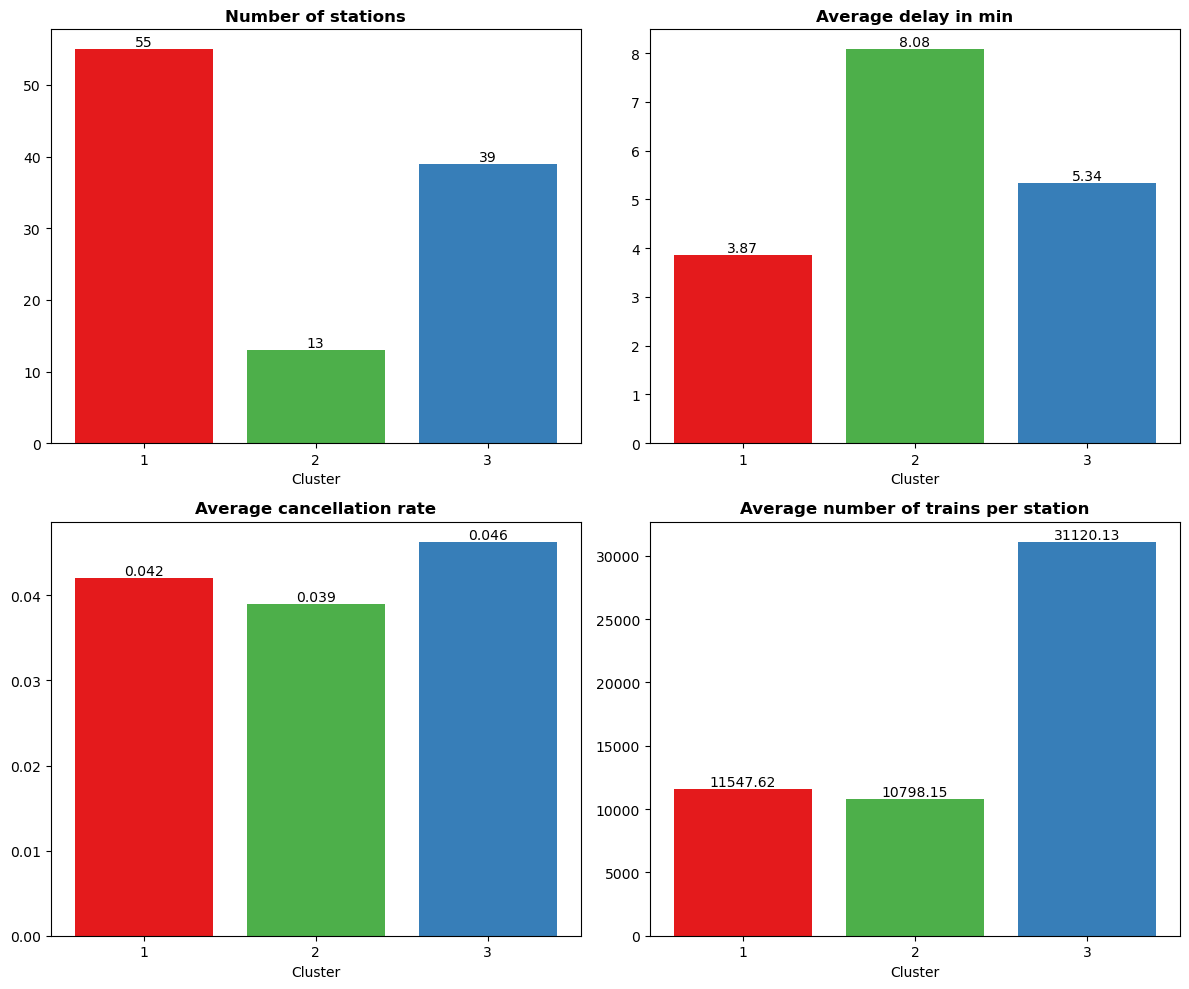

In [77]:

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

plot_data = cluster_summary.reset_index()

color_map = {
    '1': '#e41a1c',  
    '2': '#4daf4a',  
    '3': '#377eb8'   
}

features_to_plot = [
    'number_of_stations',
    'avg_delay_min', 
    'cancellation_rate', 
    'total_trains'
]

title_map = {
    'number_of_stations': 'Number of stations',
    'avg_delay_min': 'Average delay in min',
    'cancellation_rate': 'Average cancellation rate',
    'total_trains': 'Average number of trains per station'
}

for i, col in enumerate(features_to_plot):
    ax = axes[i]
    
    bar_colors = [color_map[str(label)] for label in plot_data['Cluster_Label']]
    
    bars = ax.bar(
        plot_data['Cluster_Label'].astype(str), 
        plot_data[col],                         
        color=bar_colors 
    )

    clean_title = title_map[col]
    
    ax.set_title(clean_title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Cluster', fontsize=10)
    
    for bar in bars:
        height = bar.get_height()
        
        if col == 'number_of_stations':
            text_label = f'{int(height)}'
        elif col == 'cancellation_rate':
            text_label = f'{height:.3f}'
        else:
            text_label = f'{height:.2f}'
            
        ax.text(
            bar.get_x() + bar.get_width() / 2, 
            height, 
            text_label, 
            ha='center', 
            va='bottom',
            fontsize=10
        )
        
plt.tight_layout()
plt.show()

In [78]:
grouped_stations = station_profiles.groupby('Cluster_Label')

for cluster_id, cluster_data in grouped_stations:
    station_names_list = cluster_data['station_name'].tolist()
    print(f"Cluster {cluster_id}:")
    print(", ".join(station_names_list))

Cluster 1:
Aachen Hbf, Aschaffenburg Hbf, Bad Oldesloe, Bamberg, Berlin Potsdamer Platz, Berlin Südkreuz, Berlin-Lichtenberg, Berlin-Wannsee, Bietigheim-Bissingen, Bochum Hbf, Braunschweig Hbf, Bruchsal, Chemnitz Hbf, Cottbus Hbf, Darmstadt Hbf, Flughafen BER, Frankfurt (Oder), Freiburg (Breisgau) Hbf, Fürth (Bay) Hbf, Gießen, Halle (Saale) Hbf, Hamburg Dammtor, Hanau Hbf, Herford, Hildesheim Hbf, Ingolstadt Hbf, Kaiserslautern Hbf, Kassel Hbf, Kiel Hbf, Landshut (Bay) Hbf, Ludwigshafen (Rhein) Hbf, Lübeck Hbf, Magdeburg Hbf, Mönchengladbach Hbf, Neumünster, Neuss Hbf, Neustadt (Weinstr) Hbf, Offenburg, Oldenburg (Oldb) Hbf, Paderborn Hbf, Pforzheim Hbf, Plochingen, Potsdam Hbf, Regensburg Hbf, Rheine, Rosenheim, Rostock Hbf, Saarbrücken Hbf, Singen (Hohentwiel), Solingen Hbf, Trier Hbf, Tübingen Hbf, Weimar, Wiesbaden Hbf, Worms Hbf
Cluster 2:
Bonn Hbf, Fulda, Gelsenkirchen Hbf, Göttingen, Hagen Hbf, Hamm (Westf) Hbf, Kassel-Wilhelmshöhe, Koblenz Hbf, Lüneburg, Osnabrück Hbf, Uelzen, 

Mapping stations to their regions and comparing clusters by regions

In [79]:
# Complete mapping of stations to their clusters and regions
data = [
    # Cluster 1
    {"station_name": "Aachen Hbf", "Cluster_Label": 1, "region": "North Rhine-Westphalia"},
    {"station_name": "Aschaffenburg Hbf", "Cluster_Label": 1, "region": "Bavaria"},
    {"station_name": "Bad Oldesloe", "Cluster_Label": 1, "region": "Schleswig-Holstein"},
    {"station_name": "Bamberg", "Cluster_Label": 1, "region": "Bavaria"},
    {"station_name": "Berlin Potsdamer Platz", "Cluster_Label": 1, "region": "Berlin"},
    {"station_name": "Berlin Südkreuz", "Cluster_Label": 1, "region": "Berlin"},
    {"station_name": "Berlin-Lichtenberg", "Cluster_Label": 1, "region": "Berlin"},
    {"station_name": "Berlin-Wannsee", "Cluster_Label": 1, "region": "Berlin"},
    {"station_name": "Bietigheim-Bissingen", "Cluster_Label": 1, "region": "Baden-Württemberg"},
    {"station_name": "Bochum Hbf", "Cluster_Label": 1, "region": "North Rhine-Westphalia"},
    {"station_name": "Braunschweig Hbf", "Cluster_Label": 1, "region": "Lower Saxony"},
    {"station_name": "Bruchsal", "Cluster_Label": 1, "region": "Baden-Württemberg"},
    {"station_name": "Chemnitz Hbf", "Cluster_Label": 1, "region": "Saxony"},
    {"station_name": "Cottbus Hbf", "Cluster_Label": 1, "region": "Brandenburg"},
    {"station_name": "Darmstadt Hbf", "Cluster_Label": 1, "region": "Hesse"},
    {"station_name": "Flughafen BER", "Cluster_Label": 1, "region": "Brandenburg"},
    {"station_name": "Frankfurt (Oder)", "Cluster_Label": 1, "region": "Brandenburg"},
    {"station_name": "Freiburg (Breisgau) Hbf", "Cluster_Label": 1, "region": "Baden-Württemberg"},
    {"station_name": "Fürth (Bay) Hbf", "Cluster_Label": 1, "region": "Bavaria"},
    {"station_name": "Gießen", "Cluster_Label": 1, "region": "Hesse"},
    {"station_name": "Halle (Saale) Hbf", "Cluster_Label": 1, "region": "Saxony-Anhalt"},
    {"station_name": "Hamburg Dammtor", "Cluster_Label": 1, "region": "Hamburg"},
    {"station_name": "Hanau Hbf", "Cluster_Label": 1, "region": "Hesse"},
    {"station_name": "Herford", "Cluster_Label": 1, "region": "North Rhine-Westphalia"},
    {"station_name": "Hildesheim Hbf", "Cluster_Label": 1, "region": "Lower Saxony"},
    {"station_name": "Ingolstadt Hbf", "Cluster_Label": 1, "region": "Bavaria"},
    {"station_name": "Kaiserslautern Hbf", "Cluster_Label": 1, "region": "Rhineland-Palatinate"},
    {"station_name": "Kassel Hbf", "Cluster_Label": 1, "region": "Hesse"},
    {"station_name": "Kiel Hbf", "Cluster_Label": 1, "region": "Schleswig-Holstein"},
    {"station_name": "Landshut (Bay) Hbf", "Cluster_Label": 1, "region": "Bavaria"},
    {"station_name": "Ludwigshafen (Rhein) Hbf", "Cluster_Label": 1, "region": "Rhineland-Palatinate"},
    {"station_name": "Lübeck Hbf", "Cluster_Label": 1, "region": "Schleswig-Holstein"},
    {"station_name": "Magdeburg Hbf", "Cluster_Label": 1, "region": "Saxony-Anhalt"},
    {"station_name": "Mönchengladbach Hbf", "Cluster_Label": 1, "region": "North Rhine-Westphalia"},
    {"station_name": "Neumünster", "Cluster_Label": 1, "region": "Schleswig-Holstein"},
    {"station_name": "Neuss Hbf", "Cluster_Label": 1, "region": "North Rhine-Westphalia"},
    {"station_name": "Neustadt (Weinstr) Hbf", "Cluster_Label": 1, "region": "Rhineland-Palatinate"},
    {"station_name": "Offenburg", "Cluster_Label": 1, "region": "Baden-Württemberg"},
    {"station_name": "Oldenburg (Oldb) Hbf", "Cluster_Label": 1, "region": "Lower Saxony"},
    {"station_name": "Paderborn Hbf", "Cluster_Label": 1, "region": "North Rhine-Westphalia"},
    {"station_name": "Pforzheim Hbf", "Cluster_Label": 1, "region": "Baden-Württemberg"},
    {"station_name": "Plochingen", "Cluster_Label": 1, "region": "Baden-Württemberg"},
    {"station_name": "Potsdam Hbf", "Cluster_Label": 1, "region": "Brandenburg"},
    {"station_name": "Regensburg Hbf", "Cluster_Label": 1, "region": "Bavaria"},
    {"station_name": "Rheine", "Cluster_Label": 1, "region": "North Rhine-Westphalia"},
    {"station_name": "Rosenheim", "Cluster_Label": 1, "region": "Bavaria"},
    {"station_name": "Rostock Hbf", "Cluster_Label": 1, "region": "Mecklenburg-Vorpommern"},
    {"station_name": "Saarbrücken Hbf", "Cluster_Label": 1, "region": "Saarland"},
    {"station_name": "Singen (Hohentwiel)", "Cluster_Label": 1, "region": "Baden-Württemberg"},
    {"station_name": "Solingen Hbf", "Cluster_Label": 1, "region": "North Rhine-Westphalia"},
    {"station_name": "Trier Hbf", "Cluster_Label": 1, "region": "Rhineland-Palatinate"},
    {"station_name": "Tübingen Hbf", "Cluster_Label": 1, "region": "Baden-Württemberg"},
    {"station_name": "Weimar", "Cluster_Label": 1, "region": "Thuringia"},
    {"station_name": "Wiesbaden Hbf", "Cluster_Label": 1, "region": "Hesse"},
    {"station_name": "Worms Hbf", "Cluster_Label": 1, "region": "Rhineland-Palatinate"},
    
    # Cluster 2
    {"station_name": "Bonn Hbf", "Cluster_Label": 2, "region": "North Rhine-Westphalia"},
    {"station_name": "Fulda", "Cluster_Label": 2, "region": "Hesse"},
    {"station_name": "Gelsenkirchen Hbf", "Cluster_Label": 2, "region": "North Rhine-Westphalia"},
    {"station_name": "Göttingen", "Cluster_Label": 2, "region": "Lower Saxony"},
    {"station_name": "Hagen Hbf", "Cluster_Label": 2, "region": "North Rhine-Westphalia"},
    {"station_name": "Hamm (Westf) Hbf", "Cluster_Label": 2, "region": "North Rhine-Westphalia"},
    {"station_name": "Kassel-Wilhelmshöhe", "Cluster_Label": 2, "region": "Hesse"},
    {"station_name": "Koblenz Hbf", "Cluster_Label": 2, "region": "Rhineland-Palatinate"},
    {"station_name": "Lüneburg", "Cluster_Label": 2, "region": "Lower Saxony"},
    {"station_name": "Osnabrück Hbf", "Cluster_Label": 2, "region": "Lower Saxony"},
    {"station_name": "Uelzen", "Cluster_Label": 2, "region": "Lower Saxony"},
    {"station_name": "Wolfsburg Hbf", "Cluster_Label": 2, "region": "Lower Saxony"},
    {"station_name": "Würzburg Hbf", "Cluster_Label": 2, "region": "Bavaria"},
    
    # Cluster 3
    {"station_name": "Augsburg Hbf", "Cluster_Label": 3, "region": "Bavaria"},
    {"station_name": "Berlin Friedrichstraße", "Cluster_Label": 3, "region": "Berlin"},
    {"station_name": "Berlin Gesundbrunnen", "Cluster_Label": 3, "region": "Berlin"},
    {"station_name": "Berlin Hauptbahnhof", "Cluster_Label": 3, "region": "Berlin"},
    {"station_name": "Berlin Ostbahnhof", "Cluster_Label": 3, "region": "Berlin"},
    {"station_name": "Berlin Ostkreuz", "Cluster_Label": 3, "region": "Berlin"},
    {"station_name": "Berlin Zoologischer Garten", "Cluster_Label": 3, "region": "Berlin"},
    {"station_name": "Berlin-Spandau", "Cluster_Label": 3, "region": "Berlin"},
    {"station_name": "Bielefeld Hbf", "Cluster_Label": 3, "region": "North Rhine-Westphalia"},
    {"station_name": "Bremen Hbf", "Cluster_Label": 3, "region": "Bremen"},
    {"station_name": "Dortmund Hbf", "Cluster_Label": 3, "region": "North Rhine-Westphalia"},
    {"station_name": "Dresden Hbf", "Cluster_Label": 3, "region": "Saxony"},
    {"station_name": "Dresden-Neustadt", "Cluster_Label": 3, "region": "Saxony"},
    {"station_name": "Duisburg Hbf", "Cluster_Label": 3, "region": "North Rhine-Westphalia"},
    {"station_name": "Düsseldorf Hbf", "Cluster_Label": 3, "region": "North Rhine-Westphalia"},
    {"station_name": "Erfurt Hbf", "Cluster_Label": 3, "region": "Thuringia"},
    {"station_name": "Essen Hbf", "Cluster_Label": 3, "region": "North Rhine-Westphalia"},
    {"station_name": "Frankfurt (Main) Hbf", "Cluster_Label": 3, "region": "Hesse"},
    {"station_name": "Frankfurt (Main) Süd", "Cluster_Label": 3, "region": "Hesse"},
    {"station_name": "Hamburg Hbf", "Cluster_Label": 3, "region": "Hamburg"},
    {"station_name": "Hamburg-Altona", "Cluster_Label": 3, "region": "Hamburg"},
    {"station_name": "Hamburg-Harburg", "Cluster_Label": 3, "region": "Hamburg"},
    {"station_name": "Hannover Hbf", "Cluster_Label": 3, "region": "Lower Saxony"},
    {"station_name": "Heidelberg Hbf", "Cluster_Label": 3, "region": "Baden-Württemberg"},
    {"station_name": "Karlsruhe Hbf", "Cluster_Label": 3, "region": "Baden-Württemberg"},
    {"station_name": "Köln Hbf", "Cluster_Label": 3, "region": "North Rhine-Westphalia"},
    {"station_name": "Köln Messe/Deutz", "Cluster_Label": 3, "region": "North Rhine-Westphalia"},
    {"station_name": "Leipzig Hbf", "Cluster_Label": 3, "region": "Saxony"},
    {"station_name": "Mainz Hbf", "Cluster_Label": 3, "region": "Rhineland-Palatinate"},
    {"station_name": "Mannheim Hbf", "Cluster_Label": 3, "region": "Baden-Württemberg"},
    {"station_name": "München Hbf", "Cluster_Label": 3, "region": "Bavaria"},
    {"station_name": "München Ost", "Cluster_Label": 3, "region": "Bavaria"},
    {"station_name": "München-Pasing", "Cluster_Label": 3, "region": "Bavaria"},
    {"station_name": "Münster (Westf) Hbf", "Cluster_Label": 3, "region": "North Rhine-Westphalia"},
    {"station_name": "Nürnberg Hbf", "Cluster_Label": 3, "region": "Bavaria"},
    {"station_name": "Oberhausen Hbf", "Cluster_Label": 3, "region": "North Rhine-Westphalia"},
    {"station_name": "Stuttgart Hbf", "Cluster_Label": 3, "region": "Baden-Württemberg"},
    {"station_name": "Ulm Hbf", "Cluster_Label": 3, "region": "Baden-Württemberg"},
    {"station_name": "Wuppertal Hbf", "Cluster_Label": 3, "region": "North Rhine-Westphalia"}
]

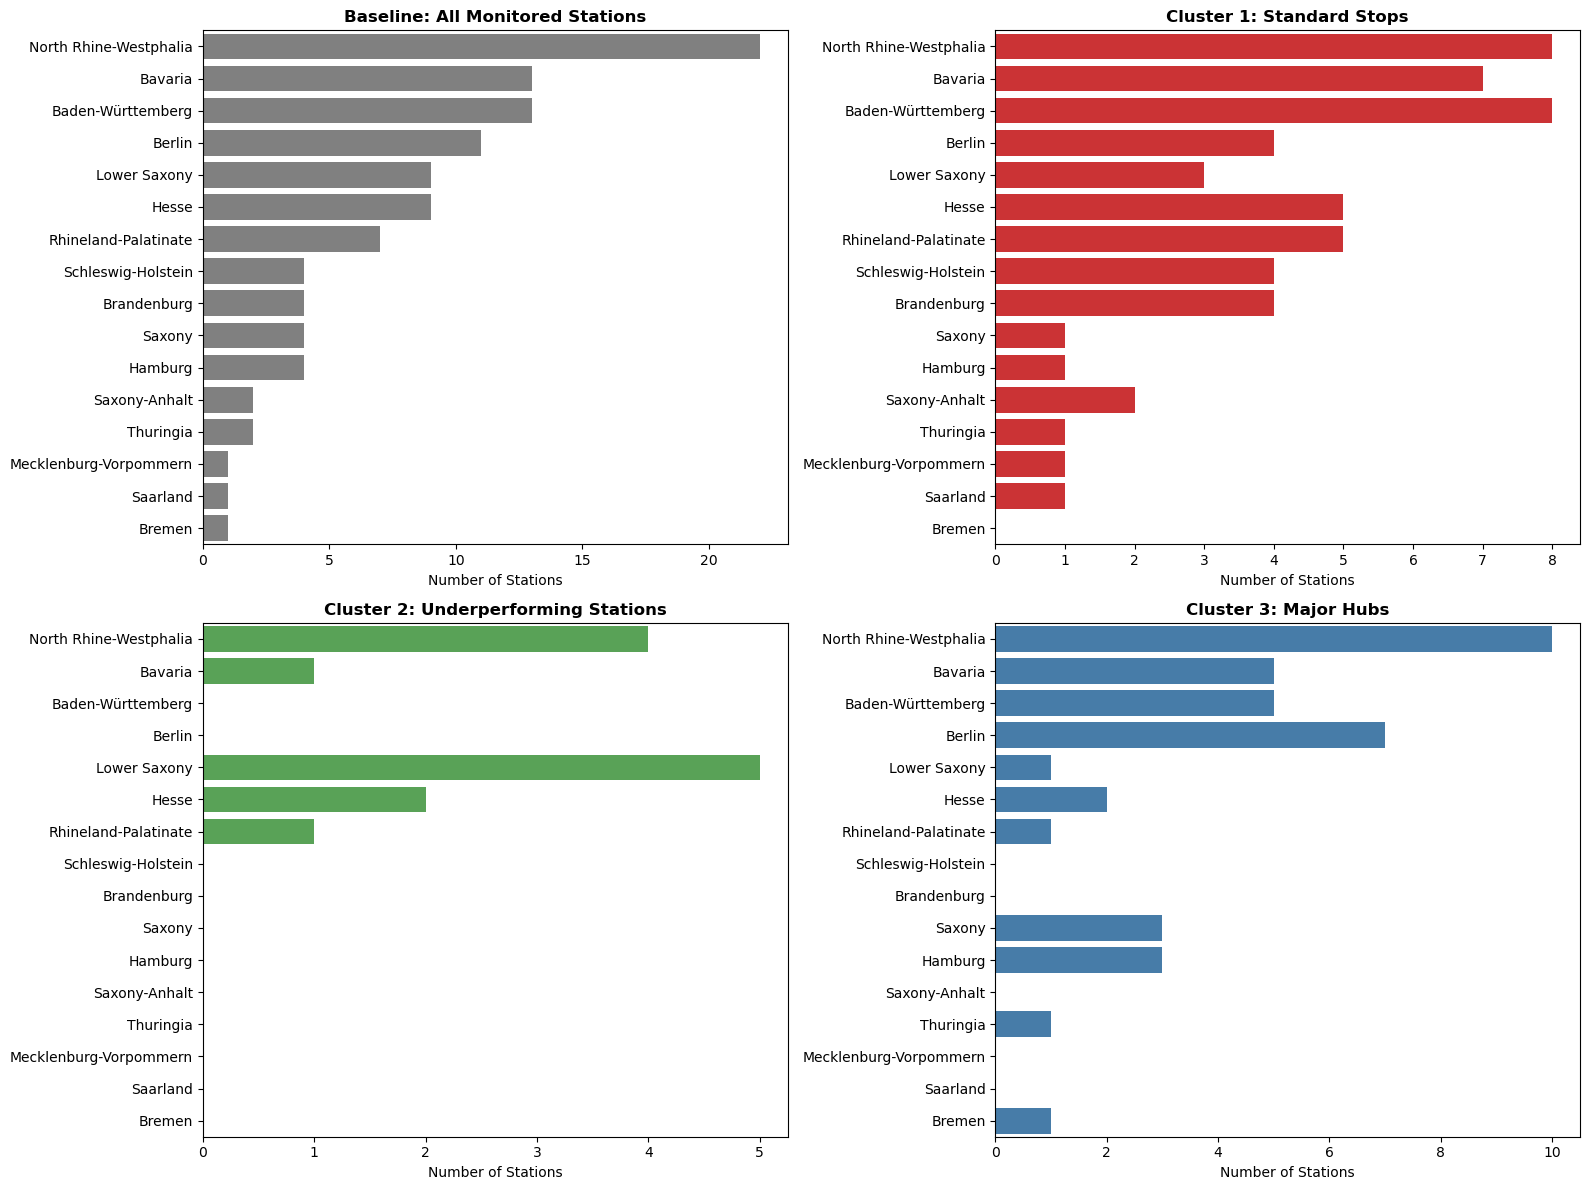

In [80]:
df_geo = pd.DataFrame(data)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

region_order = df_geo['region'].value_counts().index

# Plot 1: Baseline
sns.countplot(
    data=df_geo, 
    y='region', 
    order=region_order, 
    color='gray', 
    ax=axes[0]
)
axes[0].set_title('Baseline: All Monitored Stations', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Stations')
axes[0].set_ylabel('')

# Plot 2: Cluster 1
sns.countplot(
    data=df_geo[df_geo['Cluster_Label'] == 1], 
    y='region', 
    order=region_order, 
    color='#e41a1c', 
    ax=axes[1]
)
axes[1].set_title('Cluster 1: Standard Stops', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Stations')
axes[1].set_ylabel('')

# Plot 3: Cluster 2
sns.countplot(
    data=df_geo[df_geo['Cluster_Label'] == 2], 
    y='region', 
    order=region_order, 
    color='#4daf4a', 
    ax=axes[2]
)
axes[2].set_title('Cluster 2: Underperforming Stations', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Number of Stations')
axes[2].set_ylabel('')

# Plot 4: Cluster 3
sns.countplot(
    data=df_geo[df_geo['Cluster_Label'] == 3], 
    y='region', 
    order=region_order, 
    color='#377eb8', 
    ax=axes[3]
)
axes[3].set_title('Cluster 3: Major Hubs', fontsize=12, fontweight='bold')
axes[3].set_xlabel('Number of Stations')
axes[3].set_ylabel('')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import chi2_contingency, pearsonr

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 12,
    'figure.figsize': (12, 7)
})

MAIN_COLOR = "#2a9d8f"
ACCENT_COLOR = "#e76f51"

In [ ]:
rename_dict = {
    'station_name': 'station',
    'train_name': 'train_id',
    'delay_in_min': 'delay_min',
    'train_line_ride_id': 'ride_id',
    'train_line_station_num': 'stop_sequence'
}
df.rename(columns=rename_dict, inplace=True)

df['ride_id'] = df['ride_id'].apply(lambda x: '{:.0f}'.format(x) if pd.notnull(x) else 'Unknown')

df['time'] = pd.to_datetime(df['time'], dayfirst=True, errors='coerce')
df['hour'] = df['time'].dt.hour
df['day_of_week'] = df['time'].dt.day_name()
df['is_weekend'] = df['time'].dt.dayofweek.isin([5, 6])

df['is_canceled'] = df['is_canceled'].map({'TRUE': True, 'FALSE': False, True: True, False: False})

counts = df['train_type'].value_counts()
major_trains = counts[counts > 5000].index
df_major = df[df['train_type'].isin(major_trains)].copy()

# Research Question 1: Influence of Train Type

Visualizing the cancellation rate by train category and validating the significance using a Chi-Square test.

In [ ]:
type_cancellation = df_major.groupby('train_type')['is_canceled'].mean().sort_values(ascending=False) * 100
avg_rate = df['is_canceled'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(type_cancellation.index, type_cancellation.values,
              color=[ACCENT_COLOR if v > avg_rate else MAIN_COLOR for v in type_cancellation.values],
              edgecolor='white', linewidth=0.8)
ax.axhline(avg_rate, color='red', linestyle='--', linewidth=1.5, label=f'Overall Avg: {avg_rate:.2f}%')

# Value labels on each bar
for bar, val in zip(bars, type_cancellation.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Figure 1: Cancellation Risk by Train Type', pad=15)
ax.set_ylabel('Cancellation Rate (%)')
ax.set_xlabel('Train Type')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

contingency_type = pd.crosstab(df_major['train_type'], df_major['is_canceled'])
chi2, p, dof, _ = chi2_contingency(contingency_type)
print(f"Chi-Square Test: chi2={chi2:.2f}, df={dof}, p-value={p:.4e}")
print(f"Result: {'SIGNIFICANT' if p < 0.05 else 'NOT SIGNIFICANT'} (alpha=0.05)")

# Research Question 2: Temporal Patterns (Weekday vs Weekend)

Analyzing how the hour of the day and the day of the week impact service reliability.

In [ ]:
# Detailed Day of Week Analysis
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_cancel = df.groupby('day_of_week')['is_canceled'].mean() * 100
day_cancel = day_cancel.reindex(day_order)
avg_rate = df['is_canceled'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 6))
colors = [ACCENT_COLOR if d in ['Saturday', 'Sunday'] else MAIN_COLOR for d in day_order]
bars = ax.bar(day_cancel.index, day_cancel.values, color=colors, edgecolor='white', linewidth=0.8)
ax.axhline(avg_rate, color='red', linestyle='--', linewidth=1.5, label=f'Overall Avg: {avg_rate:.2f}%')

# Value labels on each bar
for bar, val in zip(bars, day_cancel.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=MAIN_COLOR, label='Weekday'),
    Patch(facecolor=ACCENT_COLOR, label='Weekend'),
    plt.Line2D([0],[0], color='red', linestyle='--', label='Overall Average')
]
ax.legend(handles=legend_elements)
ax.set_title('Figure 2: Cancellation Rate by Day of Week', pad=15)
ax.set_ylabel('Cancellation Rate (%)')
ax.set_xlabel('Day of Week')
sns.despine()
plt.tight_layout()
plt.show()

contingency_days = pd.crosstab(df['day_of_week'], df['is_canceled'])
_, p_days, _, _ = chi2_contingency(contingency_days)
print(f"Day of Week Chi-Square p-value: {p_days:.4e}")
print(f"Result: {'SIGNIFICANT' if p_days < 0.05 else 'NOT SIGNIFICANT'} (alpha=0.05)")
print()
print("Cancellation rate per day:")
for day, rate in day_cancel.items():
    tag = " ← WEEKEND" if day in ['Saturday','Sunday'] else ""
    print(f"  {day:<12}: {rate:.3f}%{tag}")

# Research Question 3: Geographical Impact

Identifying the top 10 stations with the highest cancellation rates.

In [ ]:
station_stats = df.groupby('station').agg(
    total=('is_canceled', 'count'),
    rate=('is_canceled', 'mean')
)
station_stats['rate'] *= 100
top_stations = station_stats[station_stats['total'] > 1000].sort_values(by='rate', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_stations.index, top_stations['rate'], color=ACCENT_COLOR, edgecolor='white')
for bar, val in zip(bars, top_stations['rate']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=10, fontweight='bold')
ax.set_title('Figure 3: Top 10 High-Risk Stations\n(stations with >1,000 records)', pad=15)
ax.set_xlabel('Cancellation Rate (%)')
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.show()

print("Top 10 stations by cancellation rate:")
print(top_stations[['rate','total']].rename(columns={'rate':'Cancel Rate (%)','total':'Total Records'}).to_string())

# Multi-Factor Deep Dive

Visualizing how different train categories behave hourly across the day

In [ ]:
# Filtering for clarity (Top 5 Major Categories)
major_categories = ['Bus', 'ICE', 'RB', 'RE', 'S']
df_filtered = df_major[df_major['train_type'].isin(major_categories)].copy()

# Figure 4: Operating Patterns
type_hour_trend = df_filtered.groupby(['hour', 'train_type'])['is_canceled'].mean().reset_index()
type_hour_trend['is_canceled'] *= 100

plt.figure(figsize=(14, 7))
sns.lineplot(data=type_hour_trend, x='hour', y='is_canceled', hue='train_type', 
             palette='viridis', linewidth=2.5, marker='o')
plt.title('Figure 4: Hourly Operating Patterns by Major Train Category', pad=20)
plt.xticks(range(0, 24))
plt.ylabel('Cancellation Rate (%)')
plt.legend(title='Train Type', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

# Logistic Regression with Odds Ratios
import numpy as np
df_model = df_filtered.copy()
df_model['is_canceled_num'] = df_model['is_canceled'].astype(int)
X = pd.get_dummies(df_model[['train_type', 'hour', 'is_weekend']], drop_first=True)
X = sm.add_constant(X.astype(float))
logit_results = sm.Logit(df_model['is_canceled_num'], X).fit(disp=0)

# Clean output with odds ratios
coef_summary = pd.DataFrame({
    'Coefficient': logit_results.params,
    'Odds Ratio': np.exp(logit_results.params),
    'p-value': logit_results.pvalues,
    'Significant': logit_results.pvalues.apply(lambda p: "Yes ***" if p < 0.001 else ("Yes *" if p < 0.05 else "No"))
})
print("--- Logistic Regression: Factors Affecting Cancellation Probability ---")
print("(Odds Ratio > 1 = increases cancellation risk)")
print()
print(coef_summary.to_string())

# Advanced Insight: Delay vs. Cancellation Correlation

Investigating the mathematical relationship between station-level delays and cancellation rates.

In [ ]:
station_corr = df.groupby('station').agg(cancel_rate=('is_canceled', 'mean'), avg_delay=('delay_min', 'mean'), total=('station', 'count')).query('total > 1000')
station_corr['cancel_rate'] *= 100

plt.figure(figsize=(10, 6))
sns.regplot(data=station_corr, x='avg_delay', y='cancel_rate', scatter_kws={'alpha':0.4, 'color':MAIN_COLOR}, line_kws={'color':ACCENT_COLOR})
plt.title('Figure 5: Delay vs Cancellation Correlation')
plt.show()

corr, p_val = pearsonr(station_corr['avg_delay'], station_corr['cancel_rate'])
print(f"Correlation: {corr:.4f}, P-value: {p_val:.4e}")

# Advanced Insight: Route Fatigue (Stop Sequence)

Proving the increase in cancellation probability as a train progresses through its stops.

In [ ]:
route_fatigue = df_major.groupby('stop_sequence')['is_canceled'].mean().reset_index()
route_fatigue['is_canceled'] *= 100
route_fatigue = route_fatigue[route_fatigue['stop_sequence'] <= 30]

plt.figure(figsize=(12, 6))
sns.regplot(data=route_fatigue, x='stop_sequence', y='is_canceled', color=MAIN_COLOR, line_kws={'color':ACCENT_COLOR})
plt.title('Figure 6: Route Fatigue — Cancellation Rate vs. Stop Number in Route', pad=15)
plt.xlabel('Stop Number in Route (Stop Sequence)')
plt.ylabel('Cancellation Rate (%)')
sns.despine()
plt.tight_layout()
plt.show()

df_seq = df_major.dropna(subset=['stop_sequence'])
X_seq = sm.add_constant(df_seq['stop_sequence'].astype(float))
logit_seq = sm.Logit(df_seq['is_canceled'].astype(int), X_seq).fit(disp=0)

beta = logit_seq.params['stop_sequence']
odds = np.exp(beta)
p_seq = logit_seq.pvalues['stop_sequence']
print(f"Route Fatigue Logistic Regression:")
print(f"  Coefficient (beta): {beta:.5f}")
print(f"  Odds Ratio: {odds:.5f} — each additional stop multiplies cancellation odds by {odds:.4f}")
print(f"  p-value: {p_seq:.4e}")
print(f"  Result: {'SIGNIFICANT' if p_seq < 0.05 else 'NOT SIGNIFICANT'}")